In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Loading the dataset
from google.colab import files
uploaded = files.upload()


Saving walmart_data.csv to walmart_data.csv


In [ ]:
# Load the uploaded file
df = pd.read_csv('walmart_data.csv')

# View the first few rows
print("First 5 rows:")
display(df.head())

# Dataset Info
print("\nDataset Info:")
df.info()

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())


First 5 rows:


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB

Statistical Summary:


,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


Missing values in each column:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


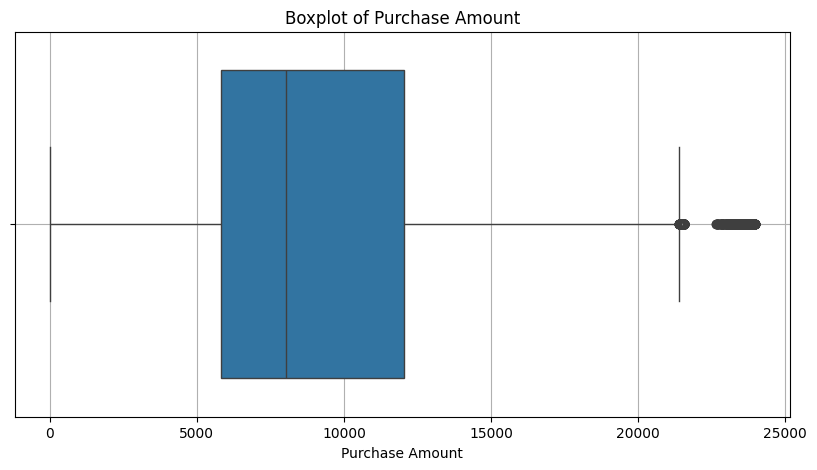


Mean of Purchase: 9263.968712959126
Median of Purchase: 8047.0


In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for outliers in 'Purchase' using boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Purchase'])
plt.title('Boxplot of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.grid(True)
plt.show()

# Compare mean and median of Purchase
mean_purchase = df['Purchase'].mean()
median_purchase = df['Purchase'].median()

print(f"\nMean of Purchase: {mean_purchase}")
print(f"Median of Purchase: {median_purchase}")


The boxplot shows the distribution of Purchase Amounts, with the majority of data concentrated below ₹15,000 and several outliers beyond ₹20,000.
Insight: A few high-value transactions (beyond ₹20,000) are statistical outliers, indicating rare but significant purchases that may skew the overall average.

In [ ]:


# Assuming your DataFrame is named 'df'
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1

# Calculate outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['Purchase'] < lower_bound) | (df['Purchase'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", outliers.shape[0])


Q1: 5823.0
Q3: 12054.0
IQR: 6231.0
Lower Bound: -3523.5
Upper Bound: 21400.5
Number of Outliers: 2677


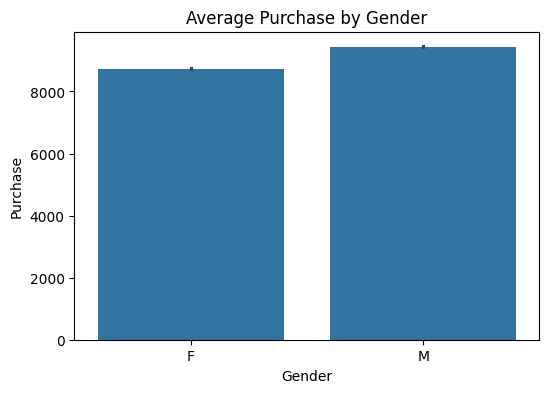

In [ ]:
# Purchase amount by Gender
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Purchase', data=df, estimator='mean')
plt.title("Average Purchase by Gender")
plt.show()


Average Purchase by Gender
This bar chart shows the average purchase amount for each gender.
Insight: Males tend to spend more on average than females.

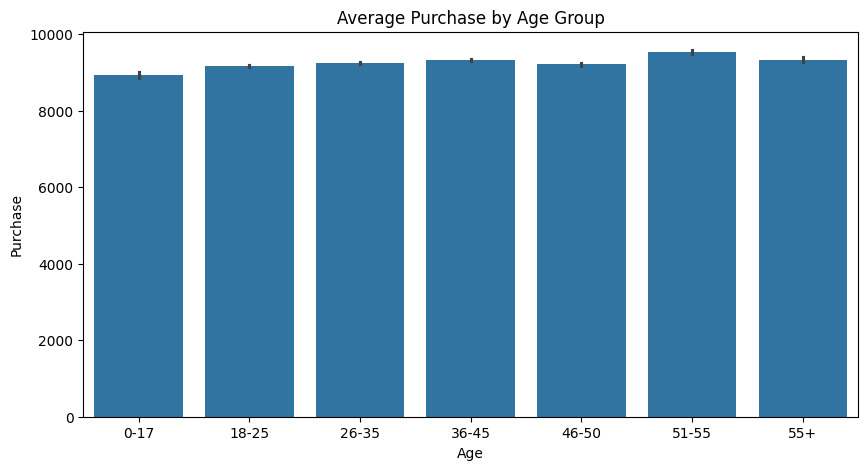

In [ ]:
# Purchase amount by Age group
plt.figure(figsize=(10,5))
sns.barplot(x='Age', y='Purchase', data=df, estimator='mean', order=sorted(df['Age'].unique()))
plt.title("Average Purchase by Age Group")
plt.show()

Average Purchase by Age Group
This bar chart illustrates the average purchase amount across different age groups.
Insight: The 51–55 age group records the highest average purchase, while the 0–17 age group spends the least.

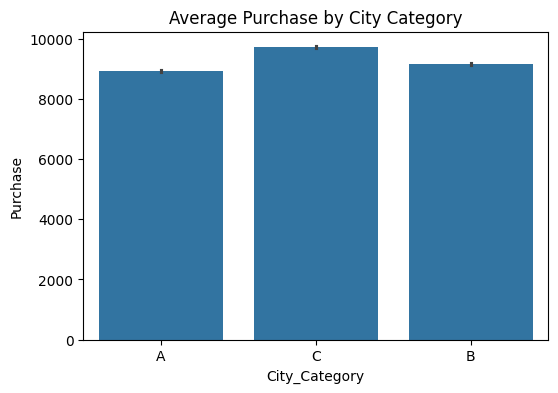

In [ ]:
# Purchase amount by City Category
plt.figure(figsize=(6,4))
sns.barplot(x='City_Category', y='Purchase', data=df, estimator='mean')
plt.title("Average Purchase by City Category")
plt.show()

Average Purchase by City Category
This bar chart compares the average purchase amount across different city categories (A, B, and C).
Insight: Users from City C have the highest average purchases, followed by City B, then City A.



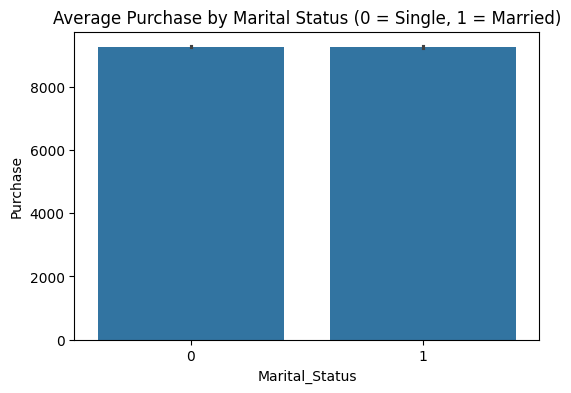

In [ ]:
# Purchase amount by Marital Status
plt.figure(figsize=(6,4))
sns.barplot(x='Marital_Status', y='Purchase', data=df, estimator='mean')
plt.title("Average Purchase by Marital Status (0 = Single, 1 = Married)")
plt.show()

Average Purchase by Marital Status
This bar chart displays the average purchase amount for single (0) and married (1) users.
Insight: There's a very small difference — singles spend slightly more than married users.

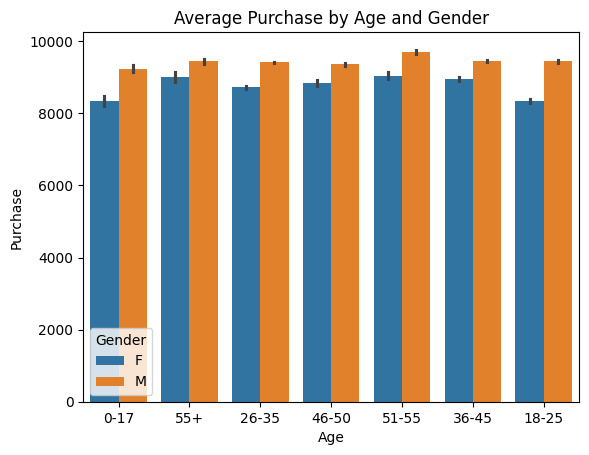

In [ ]:
sns.barplot(x='Age', y='Purchase', hue='Gender', data=df)
plt.title('Average Purchase by Age and Gender')
plt.show()


Average Purchase by Age and Gender
This grouped bar chart shows the average purchase amount for each age group, split by gender.
Insight: Males consistently spend more across all age groups, especially in the 46–55 range.



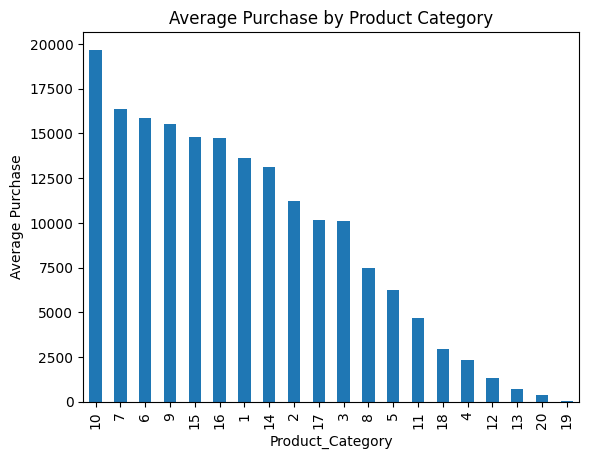

In [ ]:
df.groupby('Product_Category')['Purchase'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Purchase by Product Category')
plt.ylabel('Average Purchase')
plt.show()


Average Purchase by Product Category (from your product-wise chart)
This bar chart shows the average purchase for each product category.
Insight: Certain product categories clearly outperform others, indicating popular preferences among users.

In [ ]:
# Filter male customers
df_male = df[df['Gender'] == 'M']['Purchase']

# Now calculating 95% confidence interval
ci_male = stats.t.interval(confidence=0.95, df=len(df_male)-1, loc=df_male.mean(), scale=stats.sem(df_male))
print("95% Confidence Interval for Male Customers:", ci_male)



95% Confidence Interval for Male Customers: (np.float64(9422.019402055814), np.float64(9453.032678888716))


We are 95% confident that the average purchase amount by male customers lies between ₹9422.02 and ₹9453.03.

> Add blockquote



In [ ]:
# Filter female customer purchases
df_female = df[df['Gender'] == 'F']['Purchase']

# 95% confidence interval for female customers
ci_female = stats.t.interval(
    confidence=0.95,
    df=len(df_female)-1,
    loc=np.mean(df_female),
    scale=stats.sem(df_female)
)

print("95% Confidence Interval for Female Customers:", ci_female)


95% Confidence Interval for Female Customers: (np.float64(8709.21132117373), np.float64(8759.92020913722))


We are 95% confident that the average purchase amount by female customers lies between ₹8709.21 and ₹8759.92

Women are spending less per transaction than men.

The confidence intervals do not overlap, meaning the difference in average spending is statistically significant.

Walmart can use this finding to:

* Design targeted promotions or discounts for female customers.

* Explore product preferences among men and women to optimize offerings.

* Create personalized marketing strategies based on gender-based spending behavior.

**95% Confidence Interval for Married vs Unmarried**

In [ ]:
df_married = df[df['Marital_Status'] == 1]['Purchase']
df_unmarried = df[df['Marital_Status'] == 0]['Purchase']


In [ ]:
# Married
ci_married = stats.t.interval(
    confidence=0.95,
    df=len(df_married) - 1,
    loc=df_married.mean(),
    scale=stats.sem(df_married)
)

# Unmarried
ci_unmarried = stats.t.interval(
    confidence=0.95,
    df=len(df_unmarried) - 1,
    loc=df_unmarried.mean(),
    scale=stats.sem(df_unmarried)
)

ci_married, ci_unmarried


((np.float64(9240.460315792989), np.float64(9281.888832371758)),
 (np.float64(9248.616353737028), np.float64(9283.198884105985)))

Unmarried customers spend slightly more than married ones, but the confidence intervals overlap, so the difference is not statistically significant.

In [ ]:
for age_group in df['Age'].unique():
    purchases = df[df['Age'] == age_group]['Purchase']
    ci = stats.t.interval(
        confidence=0.95,
        df=len(purchases) - 1,
        loc=purchases.mean(),
        scale=stats.sem(purchases)
    )
    print(f"{age_group}: {ci}")


0-17: (np.float64(8851.941436361221), np.float64(9014.987844528727))
55+: (np.float64(9269.295063935433), np.float64(9403.265854963376))
26-35: (np.float64(9231.733560884022), np.float64(9273.647704855754))
46-50: (np.float64(9163.08393647555), np.float64(9254.167458461105))
51-55: (np.float64(9483.989875153999), np.float64(9585.626186766473))
36-45: (np.float64(9301.669084404875), np.float64(9361.032305430872))
18-25: (np.float64(9138.40756914702), np.float64(9200.919643375557))


Customers aged 51–55 spend the most, while teenagers (0–17) spend the least; spending generally increases with age until mid-50s.